In [38]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib


from collections import defaultdict
from scipy.stats import zscore
# Scikit-learn & Survival Analysis
from sklearn import set_config
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sksurv.column import encode_categorical
from sksurv.svm import FastSurvivalSVM
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.ensemble import RandomForestRegressor
from sksurv.metrics import concordance_index_ipcw, concordance_index_censored
from sklearn.model_selection import StratifiedKFold
from sksurv.util import Surv

set_config(display="text")  # displays text representation of estimators
sns.set_style("whitegrid")

# Load Data
df = pd.read_csv("./data/X_train/clinical_train.csv")
df_eval = pd.read_csv("./data/X_test/clinical_test.csv")

maf_df = pd.read_csv("./data/X_train/molecular_train.csv")
maf_eval = pd.read_csv("./data/X_test/molecular_test.csv")

target_df = pd.read_csv("./data/target_train.csv")

print("Data Loaded.")

Data Loaded.


In [2]:
# Cell 2: Target Cleaning
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

target_df.loc[target_df['OS_YEARS'] <= 0, 'OS_YEARS'] = 1e-5  # Small positive value for non-positive survival times

# Merge target into training data
df = df.merge(target_df[['ID', 'OS_YEARS', 'OS_STATUS']], on='ID', how='inner')

In [3]:
# Cell 3: Parsing Functions

def parse_PROTEIN_CHANGE(protein):
    """Extracts the numeric position (hotspot) from protein change string."""
    protein = str(protein)
    if len(protein) == 0 or protein == 'nan':
        return 0
    # Regex to find the number in p.R882H -> 882
    match = re.search(r"(\d+)", protein)
    if match:
        return int(match.group(1))
    return 0

def parse_GENE(gene):
    """Returns the full gene name in uppercase."""
    gene = str(gene)
    if len(gene) == 0 or gene == 'nan':
        return "UNKNOWN"
    return gene.upper()

def parse_CYTO(iscn):
    """Parses ISCN strings for complex karyotypes and translocations."""
    iscn = str(iscn).upper().replace(" ", "")
    results = defaultdict(int)
    
    # 1. Detect Complex Karyotype
    clones = iscn.split("/")
    max_abnormalities = 0
    for clone in clones:
        abnormalities = re.findall(r"([+-]\d+|DEL|ADD|INV|T\(|DER)", clone)
        if len(abnormalities) > max_abnormalities:
            max_abnormalities = len(abnormalities)
    if max_abnormalities >= 3:
        results["Complex_Karyotype"] = 1

    # 2. Specific Translocations/Inversions
    structural = re.findall(r"(T|INV)\((\d+|X|Y)[;]?(\d+|X|Y)?\)", iscn)
    for type_, chrom1, chrom2 in structural:
        chrom2_str = f";{chrom2}" if chrom2 else ""
        key = f"{type_}({chrom1}{chrom2_str})"
        results[key] = 1

    # 3. Numeric changes
    numeric_changes = re.findall(r"(?<![0-9])([+-])(\d+|X|Y)(?=[,/]|$)", iscn)
    for sign, num in numeric_changes:
        key = f"{sign}{num}"
        results[key] = 1

    if not results:
        results["normal"] = 1
    return dict(results)

In [4]:
# Cell 4: Cytogenetics Processing (Fixed Fragmentation)

# Calculate Nmut
if 'Nmut' not in df.columns:
    nmut_train = maf_df.groupby('ID').size().reset_index(name='Nmut')
    nmut_test = maf_eval.groupby('ID').size().reset_index(name='Nmut')
    df = df.merge(nmut_train, on='ID', how='left').fillna({'Nmut': 0})
    df_eval = df_eval.merge(nmut_test, on='ID', how='left').fillna({'Nmut': 0})

total_features = ['Nmut']

# Parse CYTO - FIXED TO USE CONCAT INSTEAD OF FRAGMENTED ASSIGNMENT
for i, dataset in enumerate([df, df_eval]):
    cyto_dicts = dataset['CYTOGENETICS'].apply(parse_CYTO)
    cyto_df = pd.DataFrame(cyto_dicts.tolist(), index=dataset.index).fillna(0)
    
    # Use concat to avoid fragmentation
    if i == 0:
        df = pd.concat([df, cyto_df], axis=1)
    else:
        df_eval = pd.concat([df_eval, cyto_df], axis=1)

# Add only columns relevant to training data
cyto_cols = [c for c in df.columns if any(x in c for x in ['+', '-', 't(', 'inv(', 'Complex', 'normal'])]
total_features.extend(cyto_cols)

In [5]:
# Cell 5: Molecular Features (Optimized)

def process_molecular_features():
    global df, df_eval, total_features
    
    # 1. GENE features (Weighted by Max VAF)
    print("Processing Genes...")
    maf_df['GENE_CLEAN'] = maf_df['GENE'].apply(parse_GENE)
    maf_eval['GENE_CLEAN'] = maf_eval['GENE'].apply(parse_GENE)
    
    gene_pivot_train = maf_df.pivot_table(index='ID', columns='GENE_CLEAN', values='VAF', aggfunc='max', fill_value=0)
    gene_pivot_test = maf_eval.pivot_table(index='ID', columns='GENE_CLEAN', values='VAF', aggfunc='max', fill_value=0)
    
    # Rename columns
    gene_pivot_train.columns = [f"GENE_{c}" for c in gene_pivot_train.columns]
    gene_pivot_test.columns = [f"GENE_{c}" for c in gene_pivot_test.columns]
    
    # Align columns: Ensure test has exact same columns as train
    gene_pivot_test = gene_pivot_test.reindex(columns=gene_pivot_train.columns, fill_value=0)
            
    # Merge
    df = df.merge(gene_pivot_train, on='ID', how='left').fillna(0)
    df_eval = df_eval.merge(gene_pivot_test, on='ID', how='left').fillna(0)
    
    total_features.extend(gene_pivot_train.columns.tolist())
    
    # 2. EFFECT and PROTEIN_CHANGE (One-Hot)
    for feature in ['EFFECT', 'PROTEIN_CHANGE']:
        print(f"Processing {feature}...")
        
        if feature == 'PROTEIN_CHANGE':
            maf_df['temp_feat'] = maf_df[feature].apply(parse_PROTEIN_CHANGE)
            maf_eval['temp_feat'] = maf_eval[feature].apply(parse_PROTEIN_CHANGE)
        else:
            maf_df['temp_feat'] = maf_df[feature]
            maf_eval['temp_feat'] = maf_eval[feature]
            
        dummies_train = pd.get_dummies(maf_df['temp_feat'], prefix=feature)
        dummies_train['ID'] = maf_df['ID']
        agg_train = dummies_train.groupby('ID').max()
        
        dummies_test = pd.get_dummies(maf_eval['temp_feat'], prefix=feature)
        dummies_test['ID'] = maf_eval['ID']
        agg_test = dummies_test.groupby('ID').max()
        
        # Align columns
        agg_test = agg_test.reindex(columns=agg_train.columns, fill_value=0)
        
        # Merge
        df = df.merge(agg_train, on='ID', how='left').fillna(0)
        df_eval = df_eval.merge(agg_test, on='ID', how='left').fillna(0)
        
        total_features.extend(list(agg_train.columns))

process_molecular_features()

Processing Genes...
Processing EFFECT...
Processing PROTEIN_CHANGE...


In [6]:
# Cell 6: Interactions & Clinical Data (Updated with IterativeImputer)

def add_interactions(data):
    if 'GENE_NPM1' in data.columns and 'GENE_FLT3' in data.columns:
        data['INT_NPM1_pos_FLT3_neg'] = ((data['GENE_NPM1'] > 0) & (data['GENE_FLT3'] == 0)).astype(int)
    if 'GENE_TP53' in data.columns and 'Complex_Karyotype' in data.columns:
        data['INT_TP53_Complex'] = ((data['GENE_TP53'] > 0) & (data['Complex_Karyotype'] > 0)).astype(int)
    return data

df = add_interactions(df)
df_eval = add_interactions(df_eval)

# Add interactions if they exist
for feat in ['INT_NPM1_pos_FLT3_neg', 'INT_TP53_Complex']:
    if feat in df.columns:
        total_features.append(feat)

# Clinical Transforms
clinical_cols = ['BM_BLAST', 'WBC', 'ANC', 'PLT', 'HB', 'MONOCYTES']
for col in clinical_cols:
    # Log transform first to normalize skewed distributions before imputation
    df[col] = np.log1p(df[col])
    df_eval[col] = np.log1p(df_eval[col])

# --- CHANGED: Iterative Imputation ---
print("Starting Iterative Imputation on clinical variables...")

# We use a lightweight Random Forest estimator inside MICE. 
# This learns non-linear relationships (e.g., WBC vs Blasts) better than BayesianRidge.
knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')  

# Apply ONLY to clinical columns to avoid crashing on the 1000+ gene columns
df[clinical_cols] = knn_imputer.fit_transform(df[clinical_cols])
df_eval[clinical_cols] = knn_imputer.transform(df_eval[clinical_cols])
print("Imputation Complete.")

total_features.extend(clinical_cols)
# Remove duplicates
total_features = list(set([f for f in total_features if f in df.columns]))
print(f"Total Features: {len(total_features)}")

# Prepare Data
X = df[total_features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', df)

Starting Iterative Imputation on clinical variables...
Imputation Complete.
Total Features: 1773


## Finetuning the model

49.6% of records are censored


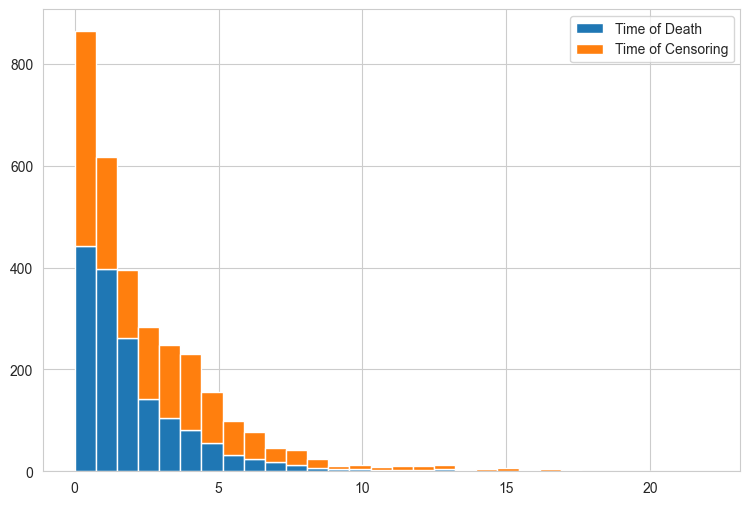

In [7]:
n_censored = y.shape[0] - y["OS_STATUS"].sum()
print(f"{n_censored / y.shape[0] * 100:.1f}% of records are censored")

plt.figure(figsize=(9, 6))
val, bins, patches = plt.hist(
    (y["OS_YEARS"][y["OS_STATUS"]], y["OS_YEARS"][~y["OS_STATUS"]]), bins=30, stacked=True
)
_ = plt.legend(patches, ["Time of Death", "Time of Censoring"])

In [8]:
estimator = FastSurvivalSVM(max_iter=1000, tol=1e-5, random_state=0)

In [41]:
def score_survival_model(model, X, y):
    prediction = model.predict(X)
    result = concordance_index_censored(y["OS_STATUS"], y["OS_YEARS"], prediction)
    return result[0]

In [47]:
param_grid = {"alpha": [2.0**v for v in range(-20, -5, 2)]}
cv = ShuffleSplit(n_splits=5, test_size=0.5, random_state=0)
gcv = GridSearchCV(estimator, param_grid, scoring=score_survival_model, n_jobs=1, refit=False, cv=cv, verbose=2)

In [48]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
gcv = gcv.fit(X, y)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ..........................alpha=9.5367431640625e-07; total time=   0.6s
[CV] END ..........................alpha=9.5367431640625e-07; total time=   0.8s
[CV] END ..........................alpha=9.5367431640625e-07; total time=   0.8s
[CV] END ..........................alpha=9.5367431640625e-07; total time=   0.7s
[CV] END ..........................alpha=9.5367431640625e-07; total time=   0.8s
[CV] END ...........................alpha=3.814697265625e-06; total time=   0.9s
[CV] END ...........................alpha=3.814697265625e-06; total time=   1.0s
[CV] END ...........................alpha=3.814697265625e-06; total time=   0.9s
[CV] END ...........................alpha=3.814697265625e-06; total time=   1.6s
[CV] END ...........................alpha=3.814697265625e-06; total time=   1.1s
[CV] END ............................alpha=1.52587890625e-05; total time=   1.4s
[CV] END ............................alpha=1.5258

In [62]:
f"{gcv.best_score_:.3f}", gcv.best_params_

('0.709', {'alpha': 1.52587890625e-05})

In [50]:
def plot_performance(gcv):
    n_splits = gcv.cv.n_splits
    cv_scores = {"alpha": [], "test_score": [], "split": []}
    order = []
    for i, params in enumerate(gcv.cv_results_["params"]):
        name = f'{params["alpha"]:.5f}'
        order.append(name)
        for j in range(n_splits):
            vs = gcv.cv_results_[f"split{j}_test_score"][i]
            cv_scores["alpha"].append(name)
            cv_scores["test_score"].append(vs)
            cv_scores["split"].append(j)
    df = pd.DataFrame.from_dict(cv_scores)
    _, ax = plt.subplots(figsize=(11, 6))
    sns.boxplot(x="alpha", y="test_score", hue="alpha", data=df, order=order, ax=ax)
    _, xtext = plt.xticks()
    for t in xtext:
        t.set_rotation("vertical")

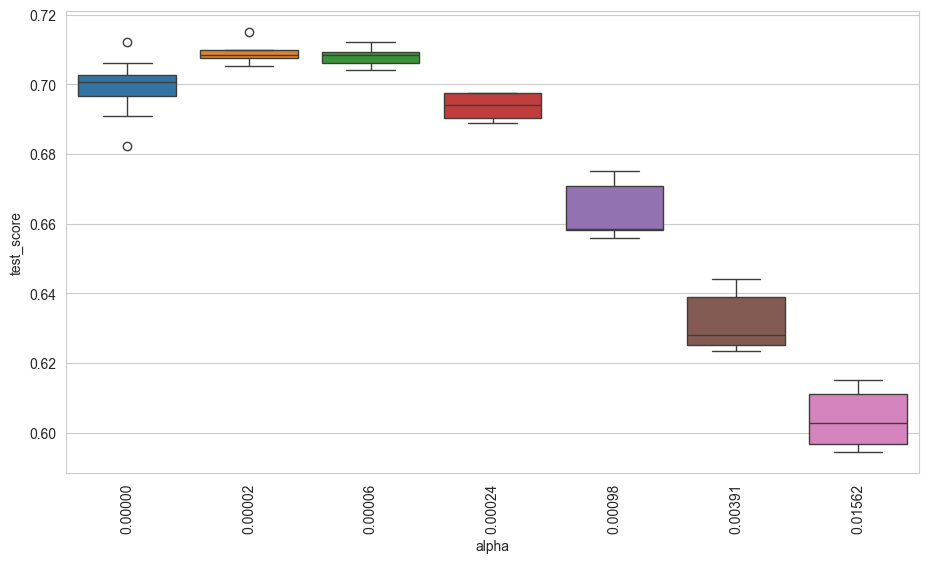

In [51]:
plot_performance(gcv)

In [52]:
estimator.set_params(**gcv.best_params_)
estimator.fit(X, y)

FastSurvivalSVM(alpha=1.52587890625e-05, max_iter=1000, optimizer='avltree',
                random_state=0, tol=1e-05)

In [60]:
pred = estimator.predict(X)
print(np.round(pred, 3))
print(y)


[ 0.201 -0.375 -0.126 ... -0.393 -0.191 -0.471]
[( True, 1.11506849) (False, 4.92876712) (False, 2.04383562) ...
 (False, 1.99726027) ( True, 0.09589041) (False, 2.29041096)]


## Kernel Survival Support Vector Machine

In [67]:
from sksurv.kernels import clinical_kernel
from sksurv.svm import FastKernelSurvivalSVM

kernel_matrix = clinical_kernel(X)

kssvm = FastKernelSurvivalSVM(optimizer="rbtree", kernel="precomputed", random_state=0)
kgcv = GridSearchCV(kssvm, param_grid, scoring=score_survival_model, n_jobs=1, refit=False, cv=cv)

AttributeError: Can only use .cat accessor with a 'category' dtype

In [ ]:
kgcv = kgcv.fit(kernel_matrix, y)